# Scaling and Balancing Visualization

This notebook visualizes the datasets produced by `src/preprocessing/scale_balance.py`.

The goal is to verify this preprocessing phase only:

- `StandardScaler` was fitted on the training split only
- validation and test were transformed using the training-fitted scaler
- SMOTE was applied only to the training set
- validation and test class distributions remain untouched
- model training is not done here

## 1. Imports

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 100)

## 2. Load Metadata

In [2]:
metadata_path = '../data/scaled_balanced/scale_balance_metadata.json'

with open(metadata_path, 'r', encoding='utf-8') as file:
    metadata = json.load(file)

print('Scaler fit on:', metadata['scaler_fit_on'])
print('SMOTE applied to:', metadata['smote_applied_to'])
print('Feature columns:', len(metadata['feature_columns']))
print('Columns excluded before loading:', len(metadata['columns_excluded_before_loading']))
print('Leakage/raw columns dropped after encoding:', len(metadata['dropped_leakage_or_raw_columns']))
print('Remaining non-numeric columns dropped:', len(metadata['dropped_non_numeric_columns_after_encoding']))
print('One-hot encoded columns:', len(metadata['one_hot_encoded_columns']))

Scaler fit on: train_data.csv only
SMOTE applied to: scaled training set only
Feature columns: 50
Columns excluded before loading: 16
Leakage/raw columns dropped after encoding: 2
Remaining non-numeric columns dropped: 2
One-hot encoded columns: 14


In [3]:
pd.DataFrame({
    'columns_excluded_before_loading': metadata['columns_excluded_before_loading']
})

,columns_excluded_before_loading
0,gh_project_name
1,gh_pr_created_at
2,gh_build_started_at
3,tr_log_lan
4,tr_log_status
5,tr_log_analyzer
6,tr_log_frameworks
7,tr_log_bool_tests_failed
8,tr_log_bool_tests_ran
9,tr_log_num_tests_ok


## 3. Load Scaled and Balanced Samples

In [4]:
paths = {
    'scaled_train': '../data/scaled_balanced/scaled_train_data.csv',
    'balanced_train': '../data/scaled_balanced/balanced_train_data.csv',
    'scaled_validation': '../data/scaled_balanced/scaled_validation_data.csv',
    'scaled_test': '../data/scaled_balanced/scaled_test_data.csv',
}

# Use samples for feature-level visualizations to keep the notebook responsive.
samples = {
    name: pd.read_csv(path, nrows=250_000, low_memory=False)
    for name, path in paths.items()
}

for name, df in samples.items():
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')

scaled_train: 250,000 rows x 51 columns
balanced_train: 250,000 rows x 51 columns
scaled_validation: 250,000 rows x 51 columns
scaled_test: 250,000 rows x 51 columns


In [5]:
samples['balanced_train'].head()

,gh_is_pr,gh_pull_req_num,gh_lang,tr_prev_build,gh_team_size,git_num_all_built_commits,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_repo_age,gh_repo_num_commits,tr_build_number,hour_of_day,day_of_week,is_weekend,total_code_churn,test_to_src_ratio,total_files_changed,is_large_commit,project_failure_rate,git_merged_with__commits_in_master,git_merged_with__fixes_in_commit,git_merged_with__merge_button,git_merged_with__unknown,git_prev_commit_resolution_status__build_found,git_prev_commit_resolution_status__merge_found,git_prev_commit_resolution_status__no_previous_build,branch_group__develop,branch_group__feature,branch_group__fix,branch_group__main,branch_group__other,branch_group__release,branch_group__unknown,tr_status
0,1.993050,0.764284,-0.194386,-0.904048,-0.208044,0.507360,68.351056,-0.077754,29.464314,-0.043513,0.0,-0.041603,-0.036643,0.298402,-0.026144,-0.022689,-0.110648,-0.007827,0.141339,0.200411,0.137753,-0.572505,-0.679541,-0.550372,0.355591,-0.461864,0.093300,0.394576,-1.066941,1.842697,2.194035,-0.043513,0.0,0.137047,-0.227586,0.265384,2.589847,-0.005351,-0.261308,-2.040297,-1.433189,1.434296,-0.018441,-0.2815,-0.095903,-0.119091,0.647071,-0.475230,-0.120754,-0.000715,1
1,1.993050,0.803688,-0.194386,2.221391,0.184865,1.531767,3.549437,-0.077754,1.354387,-0.043513,0.0,0.493075,0.788415,0.811426,-0.026144,-0.022689,-0.110648,-0.007827,0.644752,0.373539,-0.116658,-0.289843,-0.511696,-0.247589,-2.812217,0.966467,0.259415,0.465291,0.255637,-0.873547,-0.455781,-0.043513,0.0,0.929691,-0.227586,-0.942895,-0.386123,-0.005351,3.826908,-2.040297,0.697745,-0.697206,-0.018441,-0.2815,-0.095903,-0.119091,0.647071,-0.475230,-0.120754,-0.000715,0
2,1.993050,0.058115,0.948353,-0.502423,-0.557298,0.134848,1.080804,-0.077754,2.777675,-0.043513,0.0,-0.041603,-0.036643,0.111848,-0.026144,-0.022689,-0.110648,-0.007827,0.029469,-0.301464,-0.328711,0.480608,0.887689,1.197531,0.355591,0.376835,-0.359114,-0.406022,1.284309,-0.873547,-0.455781,-0.043513,0.0,0.031362,-0.227586,-0.441710,-0.386123,-0.005351,-0.261308,0.490125,0.697745,-0.697206,-0.018441,-0.2815,-0.095903,-0.119091,-1.545426,2.104244,-0.120754,-0.000715,0
3,1.993050,-0.049729,0.948353,-0.693347,-0.208044,-0.051408,2.315120,-0.077754,-0.068900,-0.043513,0.0,-0.041603,-0.036643,-0.167983,-0.026144,-0.022689,-0.110648,-0.007827,-0.138335,-0.445413,-0.385396,0.782035,2.120557,1.704455,0.355591,-0.028688,-0.648318,-0.507888,0.402591,0.212951,-0.455781,-0.043513,0.0,-0.127167,-0.227586,-0.626330,-0.386123,-0.005351,3.826908,-2.040297,0.697745,-0.697206,-0.018441,-0.2815,-0.095903,-0.119091,0.647071,-0.475230,-0.120754,-0.000715,0
4,-0.501744,-0.323486,0.948353,-0.904048,-0.731924,-0.051408,-0.153513,-0.077754,-0.068900,-0.043513,0.0,-0.041603,-0.036643,-0.167983,-0.026144,-0.022689,-0.110648,-0.007827,-0.138335,-0.410398,-0.363577,-0.391375,-0.426595,-0.430505,0.355591,1.990852,-0.499995,-0.563650,0.696497,0.756200,-0.455781,-0.043513,0.0,-0.127167,-0.227586,1.575852,-0.386123,-0.005351,-0.261308,0.490125,-1.433189,1.434296,-0.018441,-0.2815,-0.095903,-0.119091,0.647071,-0.475230,-0.120754,-0.000715,1


## 4. Full Row Counts and Target Balance

In [6]:
target_summary = []

for name, path in paths.items():
    target = pd.read_csv(path, usecols=['tr_status'], low_memory=False)['tr_status']
    counts = target.value_counts().reindex([0, 1], fill_value=0)
    total = counts.sum()

    target_summary.append({
        'dataset': name,
        'rows': total,
        'passed_0': counts.loc[0],
        'failure_1': counts.loc[1],
        'passed_percent': round(counts.loc[0] / total * 100, 2),
        'failure_percent': round(counts.loc[1] / total * 100, 2),
    })

target_summary = pd.DataFrame(target_summary)
target_summary

,dataset,rows,passed_0,failure_1,passed_percent,failure_percent
0,scaled_train,1956107,1449766,506341,74.11,25.89
1,balanced_train,2899532,1449766,1449766,50.00,50.00
2,scaled_validation,419166,310664,108502,74.11,25.89
3,scaled_test,419166,310664,108502,74.11,25.89


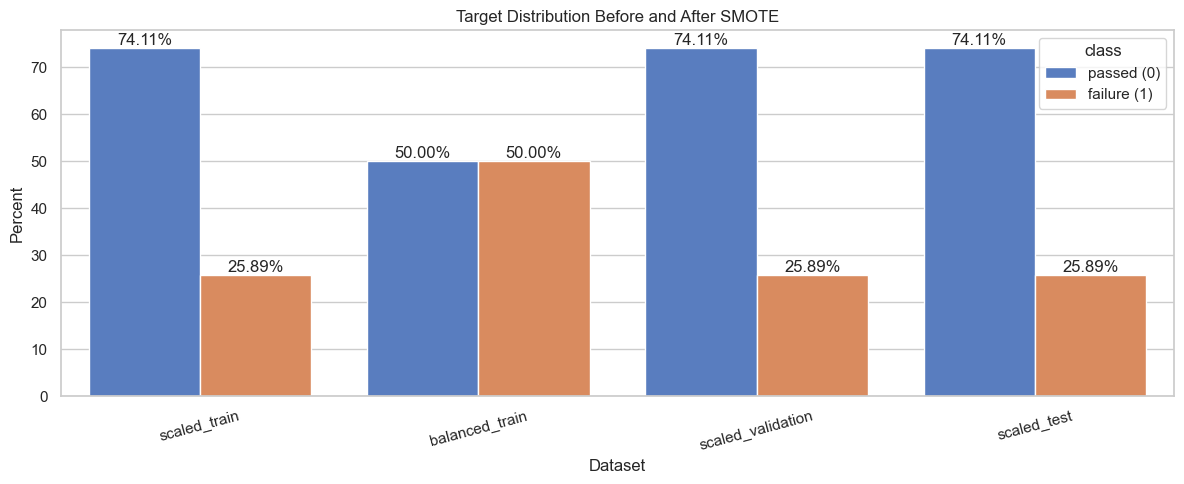

In [7]:
target_plot = target_summary.melt(
    id_vars='dataset',
    value_vars=['passed_percent', 'failure_percent'],
    var_name='class',
    value_name='percent',
)
target_plot['class'] = target_plot['class'].map({
    'passed_percent': 'passed (0)',
    'failure_percent': 'failure (1)',
})

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=target_plot, x='dataset', y='percent', hue='class')
ax.set_title('Target Distribution Before and After SMOTE')
ax.set_xlabel('Dataset')
ax.set_ylabel('Percent')
ax.tick_params(axis='x', rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

## 5. Scaling Check on Training Features

In [8]:
feature_columns = metadata['feature_columns']

scaled_train = samples['scaled_train']
scaling_check = pd.DataFrame({
    'feature': feature_columns,
    'sample_mean': scaled_train[feature_columns].mean().values,
    'sample_std': scaled_train[feature_columns].std().values,
})

scaling_check['abs_mean'] = scaling_check['sample_mean'].abs()
scaling_check.sort_values('abs_mean', ascending=False).head(15)

,feature,sample_mean,sample_std,abs_mean
47,branch_group__other,-0.004146,0.996611,0.004146
23,gh_asserts_cases_per_kloc,0.003889,1.000917,0.003889
22,gh_test_cases_per_kloc,0.003154,1.003125,0.003154
48,branch_group__release,0.003059,1.012402,0.003059
24,gh_by_core_team_member,0.002989,0.996319,0.002989
46,branch_group__main,0.002968,0.998664,0.002968
37,git_merged_with__fixes_in_commit,0.002873,1.239727,0.002873
11,gh_diff_files_added,0.002802,1.360149,0.002802
5,git_num_all_built_commits,-0.002421,0.614837,0.002421
14,gh_diff_tests_added,-0.002373,0.616735,0.002373


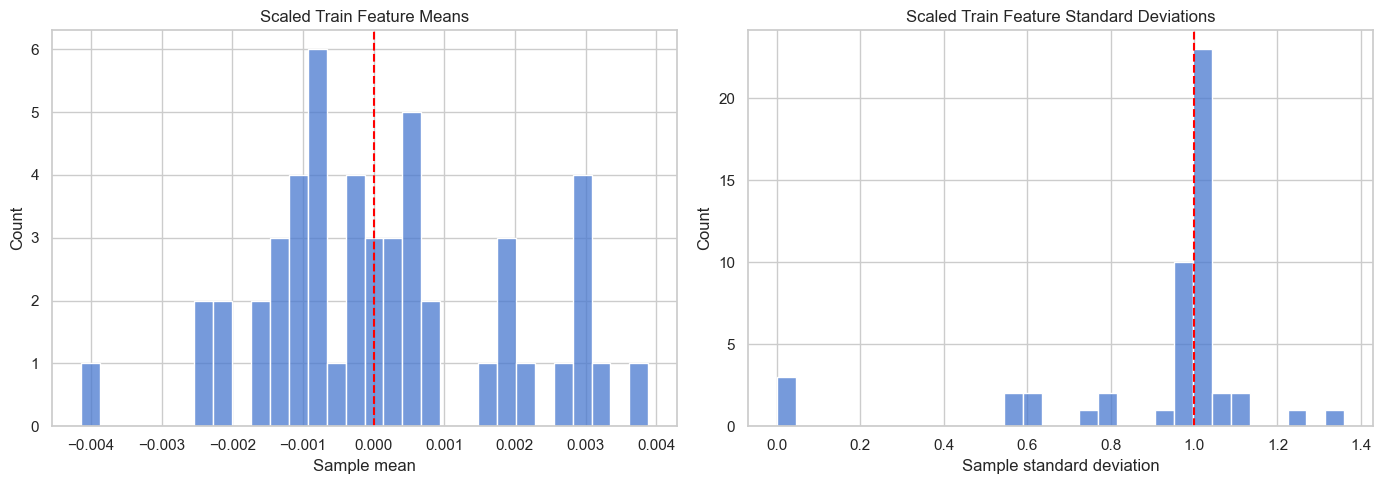

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(scaling_check['sample_mean'], bins=30, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Scaled Train Feature Means')
axes[0].set_xlabel('Sample mean')

sns.histplot(scaling_check['sample_std'], bins=30, ax=axes[1])
axes[1].axvline(1, color='red', linestyle='--')
axes[1].set_title('Scaled Train Feature Standard Deviations')
axes[1].set_xlabel('Sample standard deviation')

plt.tight_layout()
plt.show()

## 6. Feature Distribution Comparison

In [10]:
key_features = [
    'tr_duration',
    'gh_team_size',
    'gh_lang',
    'total_code_churn',
    'total_files_changed',
    'test_fail_ratio',
    'project_failure_rate',
    'is_large_commit',
]
key_features = [col for col in key_features if col in feature_columns]

comparison_sample = pd.concat(
    [
        samples['scaled_train'].assign(dataset='scaled_train'),
        samples['balanced_train'].assign(dataset='balanced_train'),
    ],
    ignore_index=True,
)

comparison_sample[key_features + ['tr_status', 'dataset']].head()

,gh_team_size,gh_lang,total_code_churn,total_files_changed,project_failure_rate,is_large_commit,tr_status,dataset
0,-0.208044,-0.194386,-0.043513,0.137047,0.265384,-0.227586,1,scaled_train
1,0.184865,-0.194386,-0.043513,0.929691,-0.942895,-0.227586,0,scaled_train
2,-0.557298,0.948353,-0.043513,0.031362,-0.441710,-0.227586,0,scaled_train
3,-0.208044,0.948353,-0.043513,-0.127167,-0.626330,-0.227586,0,scaled_train
4,-0.731924,0.948353,-0.043513,-0.127167,1.575852,-0.227586,1,scaled_train


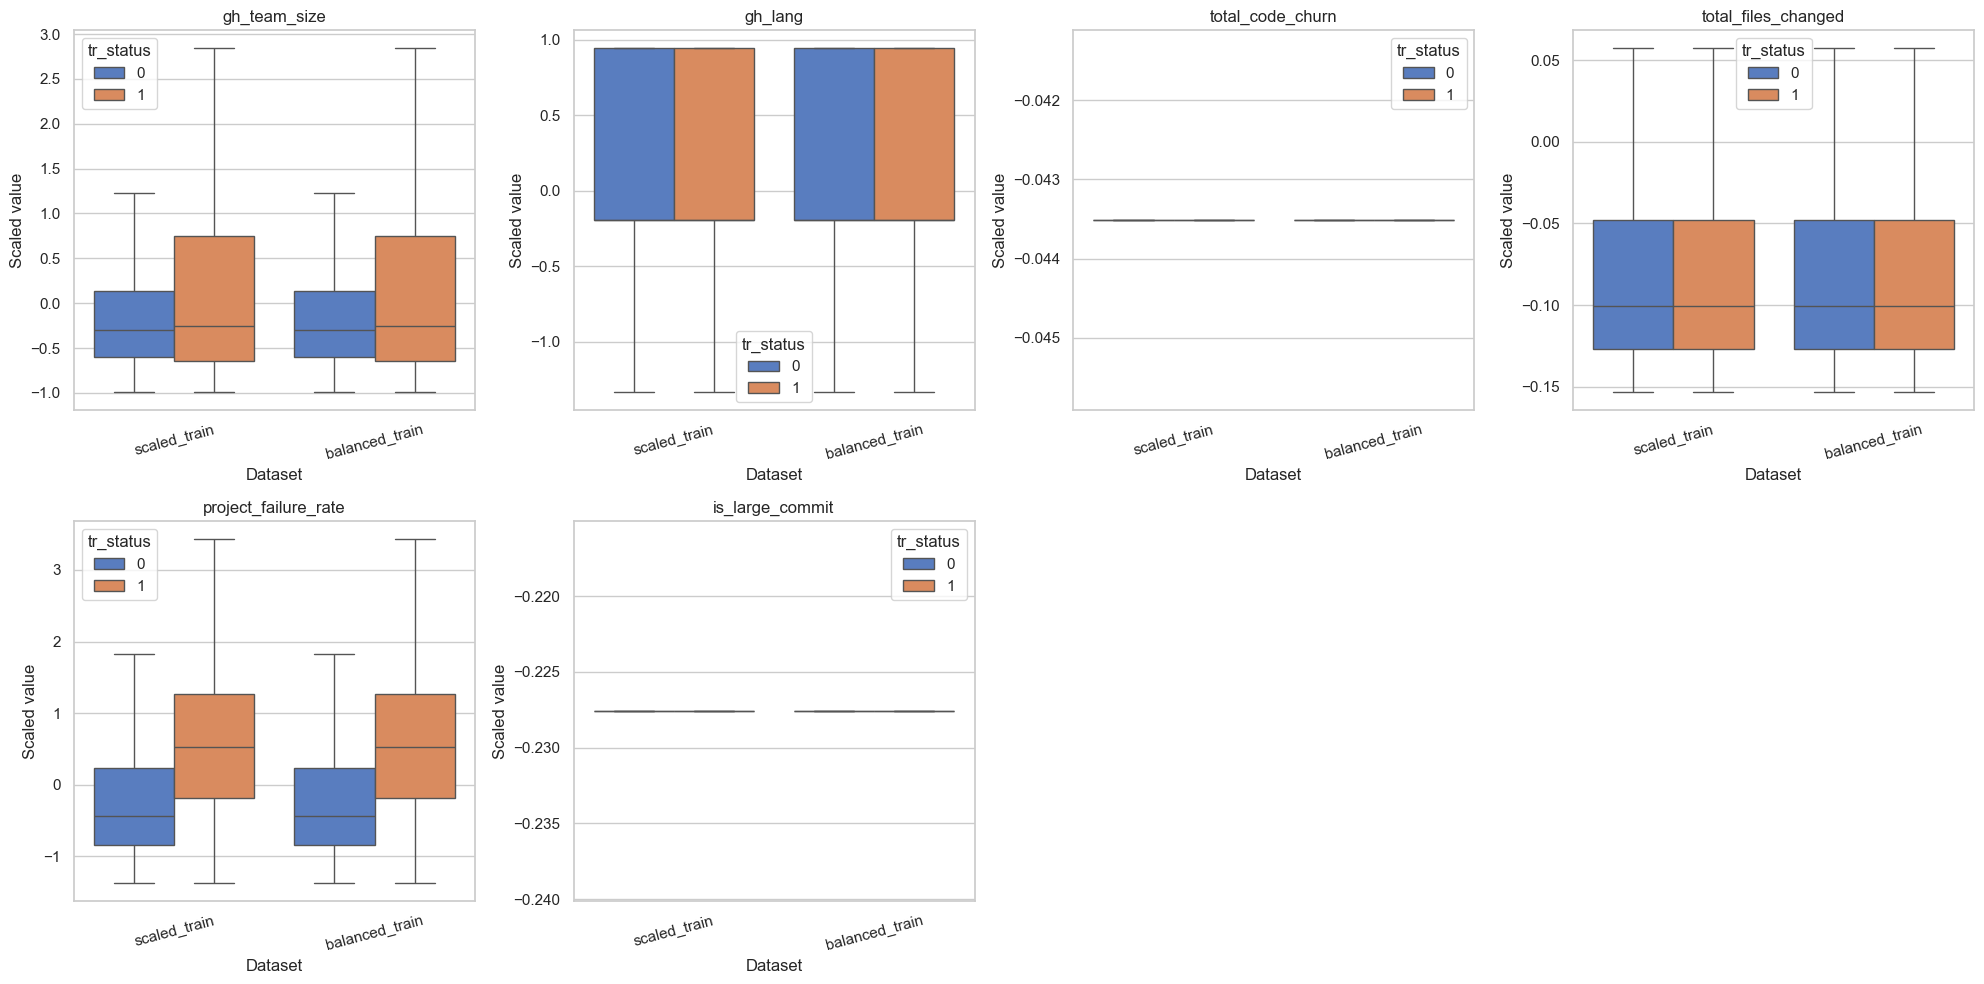

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.boxplot(data=comparison_sample, x='dataset', y=col, hue='tr_status', ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Scaled value')
    ax.tick_params(axis='x', rotation=15)

for ax in axes[len(key_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Validation and Test Remain Unbalanced

In [12]:
untouched_check = target_summary.loc[
    target_summary['dataset'].isin(['scaled_validation', 'scaled_test']),
    ['dataset', 'passed_percent', 'failure_percent']
]

untouched_check

,dataset,passed_percent,failure_percent
2,scaled_validation,74.11,25.89
3,scaled_test,74.11,25.89


## 8. Missing Values Check

In [13]:
missing_summary = []

for name, df in samples.items():
    missing_summary.append({
        'dataset': name,
        'missing_cells_in_sample': int(df.isna().sum().sum()),
        'sample_cells': int(df.shape[0] * df.shape[1]),
    })

missing_summary = pd.DataFrame(missing_summary)
missing_summary['missing_percent_in_sample'] = (
    missing_summary['missing_cells_in_sample'] / missing_summary['sample_cells'] * 100
).round(4)

missing_summary

,dataset,missing_cells_in_sample,sample_cells,missing_percent_in_sample
0,scaled_train,0,12750000,0.0
1,balanced_train,0,12750000,0.0
2,scaled_validation,0,12750000,0.0
3,scaled_test,0,12750000,0.0


## 9. Model-Ready Column Check

In [14]:
column_check = []

expected_columns = set(feature_columns + ['tr_status'])
for name, df in samples.items():
    column_check.append({
        'dataset': name,
        'column_count': df.shape[1],
        'matches_metadata_columns': set(df.columns) == expected_columns,
        'non_numeric_columns': len(df.drop(columns=['tr_status']).select_dtypes(exclude='number').columns),
    })

pd.DataFrame(column_check)

,dataset,column_count,matches_metadata_columns,non_numeric_columns
0,scaled_train,51,True,0
1,balanced_train,51,True,0
2,scaled_validation,51,True,0
3,scaled_test,51,True,0


## Summary

This notebook confirms that scaling and balancing produced model-ready numeric datasets.

**Next step:** train models using `balanced_train_data.csv`, validate using `scaled_validation_data.csv`, and reserve `scaled_test_data.csv` for final evaluation.